# Análisis Exploratorio de Datos (EDA): Generación Real por Planta en el SIN
## Escenario 03 | Sistema Interconectado Nacional de Colombia | Dataset SIMEM: `E17D25`

### 1. Contexto del Problema y Justificación Teórica
De acuerdo con la formulación del **Escenario 3** (`docs/escenarios/escenario_03.md`) y el marco metodológico de la tesis (`docs/hallazgos.md`), el reto analítico fundamental consiste en detectar anomalías en series temporales de **alta dimensión** provenientes del Sistema Interconectado Nacional (SIN).

| Dimensión | Especificación en Escenario 03 |
| :--- | :--- |
| **Dataset Objetivo** | Generación Real y Programada en Plantas de Generación (SIMEM ID: `E17D25`). |
| **Estructura Matricial** | Multivariada natural: matriz $N \text{ plantas} \times T \text{ periodos}$ desagregada por recurso y combustible. |
| **Complejidad Temporal** | Alta: estacionalidad horaria, semanal y anual, acoplamiento hidrológico, régimen térmico y precios de bolsa. |
| **Potencial de Anomalías** | Muy alto: caídas súbitas de generación, desviaciones severas entre generación programada y real, fallas forzadas de unidades y restricciones de red. |
| **Encaje Metodológico** | Excelente para modelos híbridos: Autoencoders profundos (error de reconstrucción como señal de anomalía), Isolation Forest y LOF. |

> **Objetivo de este Notebook:**
> 1. Extraer los datos oficiales del dataset `E17D25` mediante el conector `pydataxm` (`ReadSIMEM`) e integrar el contexto de demanda/generación del sistema (`ReadDB`).
> 2. Ejecutar un preprocesamiento temporal riguroso (formato datetime, extracción de `hour`, `day_of_week`, `day_name`, `is_weekend`, `month`).
> 3. Construir la matriz pivoteada $N \times T$ requerida por arquitecturas de aprendizaje profundo (Autoencoders).
> 4. Auditar la calidad de los datos, identificar valores atípicos y analizar correlaciones cruzadas entre plantas y variables operativas.

## 2. Configuración del Entorno y Dependencias

Se adoptan los estándares de calidad definidos en los escenarios 01 y 02:
- **Manipulación y Álgebra:** `pandas` y `numpy`.
- **Visualización Científica:** `matplotlib` y `seaborn` con paleta homogénea (`crest` / `seaborn-v0_8-whitegrid`).
- **Conectores Oficiales XM:** `pydataxm.pydatasimem.ReadSIMEM` para los datos tabulares del SIMEM y `pydataxm.pydataxm.ReadDB` para el portal de XM.
- **Normalización Numérica:** Escalado z-score estándar vectorizado con `numpy` y `pandas` para compatibilidad completa de entorno.

In [1]:
import datetime as dt
import re
import warnings
from typing import Dict, List, Optional, Tuple, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pydataxm.pydatasimem import CatalogSIMEM, ReadSIMEM
from pydataxm.pydataxm import ReadDB
import seaborn as sns

# Supresión de advertencias operativas de librerías externas
warnings.filterwarnings("ignore")

# Configuración del estilo visual consistente con escenario_01 y escenario_02
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
sns.set_palette("crest")

# Formato numérico y de visualización en tablas pandas
pd.set_option("display.max_columns", 35)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 3. Funciones Utilitarias con Estándar Google Docstrings (PEP 8)

Se reutilizan y refactorizan las funciones base desarrolladas en `notebook/escenario_01.ipynb` y `notebook/escenario_02.ipynb`:
1. `extraer_simem`: Conexión parametrizada con la API abierta del SIMEM para descargar datasets específicos (`E17D25`).
2. `audit_dataframe`: Auditoría estructural de completitud, cardinalidad, nulos y duplicados.
3. `compute_extended_statistics`: Estadísticos descriptivos robustos (tendencia central, dispersión, asimetría, curtosis, IQR y conteo de outliers).
4. `normalize_plant_generation`: Limpieza de registros, parseo temporal estricto y extracción de atributos de calendario.
5. `build_plant_pivot_matrix`: Construcción de la matriz $N \text{ plantas} \times T \text{ periodos}$ con imputación operativa de ceros.

In [2]:
def extraer_simem(
    dataset_id: str,
    fecha_inicio: Union[str, dt.date],
    fecha_final: Union[str, dt.date],
    filter: bool = False,
) -> pd.DataFrame:
    """Extrae datos tabulares desde la API abierta de SIMEM mediante pydataxm.

    Args:
        dataset_id: Identificador alfanumérico del conjunto de datos en SIMEM (ej. 'E17D25').
        fecha_inicio: Fecha inicial del rango de consulta en formato 'YYYY-MM-DD' o dt.date.
        fecha_final: Fecha final del rango de consulta en formato 'YYYY-MM-DD' o dt.date.
        filter: Booleano que indica si se aplican filtros configurados en el objeto.

    Returns:
        pd.DataFrame: DataFrame con los registros recuperados de la API de SIMEM.

    Raises:
        ValueError: Si los parámetros de fecha son inválidos o no se recuperan datos.
    """
    start_str = (
        fecha_inicio.strftime("%Y-%m-%d")
        if isinstance(fecha_inicio, dt.date)
        else str(fecha_inicio)
    )
    end_str = (
        fecha_final.strftime("%Y-%m-%d")
        if isinstance(fecha_final, dt.date)
        else str(fecha_final)
    )

    simem = ReadSIMEM(dataset_id=dataset_id, start_date=start_str, end_date=end_str)
    df = simem.main(filter=filter)
    if df is None or len(df) == 0:
        raise ValueError(f"No se obtuvieron registros para el dataset {dataset_id} entre {start_str} y {end_str}.")
    return df


def audit_dataframe(df: pd.DataFrame, dataset_name: str = "Dataset") -> pd.DataFrame:
    """Realiza una auditoría estructural completa sobre un DataFrame de pandas.

    Calcula conteo de no nulos, porcentaje de faltantes, tipos de datos,
    cardinalidad de valores únicos y duplicidad global.

    Args:
        df: DataFrame que se desea inspeccionar.
        dataset_name: Etiqueta descriptiva para los mensajes de diagnóstico.

    Returns:
        pd.DataFrame: Tabla resumen con las métricas de calidad y dimensiones.
    """
    summary = pd.DataFrame(
        {
            "Columna": df.columns,
            "Tipo_Dato": df.dtypes.astype(str).values,
            "Registros": len(df),
            "No_Nulos": df.notna().sum().values,
            "Nulos": df.isna().sum().values,
            "Pct_Nulos": (df.isna().mean() * 100).round(2).values,
            "Valores_Unicos": df.nunique().values,
        }
    )
    print(f"[{dataset_name}] Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
    print(f"[{dataset_name}] Filas duplicadas completas: {df.duplicated().sum():,}")
    return summary


def compute_extended_statistics(
    series: pd.Series, variable_name: str = "Variable"
) -> pd.Series:
    """Calcula estadísticas descriptivas avanzadas para una serie univariada.

    Computa medidas de tendencia central, dispersión, asimetría de Fisher-Pearson,
    curtosis de Fisher, rango intercuartílico (IQR) y umbrales de atípicos de Tukey.

    Args:
        series: Serie de pandas con valores numéricos continuos.
        variable_name: Nombre semántico de la variable analizada.

    Returns:
        pd.Series: Vector con las estadísticas descriptivas calculadas.
    """
    clean_series = pd.to_numeric(series, errors="coerce").dropna()
    q1 = clean_series.quantile(0.25)
    q3 = clean_series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = clean_series[(clean_series < lower_bound) | (clean_series > upper_bound)]

    stats = {
        "Variable": variable_name,
        "Observaciones": int(len(clean_series)),
        "Media": clean_series.mean(),
        "Desv_Estandar": clean_series.std(),
        "Coef_Variacion_%": (
            (clean_series.std() / clean_series.mean() * 100)
            if clean_series.mean() != 0
            else np.nan
        ),
        "Minimo": clean_series.min(),
        "Q1 (25%)": q1,
        "Mediana (50%)": clean_series.median(),
        "Q3 (75%)": q3,
        "Maximo": clean_series.max(),
        "IQR": iqr,
        "Asimetria": clean_series.skew(),
        "Curtosis": clean_series.kurtosis(),
        "Outliers_IQR_Count": int(len(outliers)),
        "Outliers_IQR_%": (len(outliers) / len(clean_series) * 100),
        "Umbral_Inf_IQR": lower_bound,
        "Umbral_Sup_IQR": upper_bound,
    }
    return pd.Series(stats)


def normalize_plant_generation(df: pd.DataFrame) -> pd.DataFrame:
    """Normaliza y enriquece temporalmente los datos de generación por planta.

    Convierte el campo de fecha a tipo datetime, extrae atributos de calendario
    ('hour', 'day_of_week', 'day_name', 'month', 'is_weekend') y calcula las
    desviaciones operativas entre la generación real y la programada.

    Args:
        df: DataFrame crudo extraído de SIMEM o XM.

    Returns:
        pd.DataFrame: DataFrame enriquecido y ordenado cronológicamente.
    """
    data = df.copy()

    # Identificar y renombrar columna de fecha estándar si es necesario
    if "Fecha" in data.columns and "Date" not in data.columns:
        data["Date"] = pd.to_datetime(data["Fecha"])
    elif "Date" in data.columns:
        data["Date"] = pd.to_datetime(data["Date"])
    else:
        raise ValueError("El DataFrame debe contener una columna de fecha ('Date' o 'Fecha').")

    # Si existe una columna de hora explícita, se usa; de lo contrario, base 0
    if "Hora" in data.columns:
        data["hour"] = pd.to_numeric(data["Hora"], errors="coerce").fillna(0).astype(int)
    elif "Hour" in data.columns:
        data["hour"] = pd.to_numeric(data["Hour"], errors="coerce").fillna(0).astype(int)
    else:
        data["hour"] = data["Date"].dt.hour

    data["day_of_week"] = data["Date"].dt.dayofweek
    data["day_name"] = data["Date"].dt.day_name()
    data["month"] = data["Date"].dt.month
    data["is_weekend"] = data["day_of_week"].isin([5, 6]).astype(int)

    # Conversión estricta de métricas numéricas operativas
    for col in [
        "GeneracionRealEstimada",
        "GeneracionProgramadaDespacho",
        "GeneracionProgramadaRedespacho",
    ]:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce").fillna(0.0)

    # Cálculo de discrepancias de despacho
    if (
        "GeneracionRealEstimada" in data.columns
        and "GeneracionProgramadaRedespacho" in data.columns
    ):
        data["Delta_Redespacho"] = (
            data["GeneracionRealEstimada"] - data["GeneracionProgramadaRedespacho"]
        )

    if (
        "GeneracionRealEstimada" in data.columns
        and "GeneracionProgramadaDespacho" in data.columns
    ):
        data["Delta_Despacho"] = (
            data["GeneracionRealEstimada"] - data["GeneracionProgramadaDespacho"]
        )

    return data.sort_values(["Date", "CodigoPlanta" if "CodigoPlanta" in data.columns else "Date"]).reset_index(drop=True)


def build_plant_pivot_matrix(
    df: pd.DataFrame,
    time_col: str = "Date",
    plant_col: str = "CodigoPlanta",
    val_col: str = "GeneracionRealEstimada",
) -> pd.DataFrame:
    """Construye la matriz N plantas x T periodos requerida para detección multivariada.

    Pivotea las observaciones de generación por planta rellenando las ausencias
    con 0.0 (correspondiente a plantas no despachadas o apagadas en el intervalo).

    Args:
        df: DataFrame normalizado de generación por planta.
        time_col: Nombre de la columna de marca temporal.
        plant_col: Nombre de la columna que identifica la central generadora.
        val_col: Métrica cuantitativa a pivotear.

    Returns:
        pd.DataFrame: Matriz con índice temporal y columnas correspondientes a cada planta.
    """
    pivot = df.pivot_table(
        index=time_col,
        columns=plant_col,
        values=val_col,
        aggfunc="sum",
    ).fillna(0.0)
    return pivot


## 4. Extracción de Datos: Generación Real por Planta (`E17D25`)

Siguiendo las directrices del proyecto y el extracto de `docs/hallazgos.md`, se invoca la clase `ReadSIMEM` provista por la suite `pydataxm`. 

El conjunto `E17D25` (*"Generación Real y Programada en las Plantas de Generación"*) consolida diariamente la generación neta de todas las plantas del Sistema Interconectado Nacional (SIN), desagregada por:
- `CodigoPlanta`: Nemotécnico único de la central generadora.
- `TipoGeneracion`: Tecnología de generación primaria (Hidráulica, Térmica, Solar, Eólica, etc.).
- `TipoClasificacion`: Clasificación regulatoria del recurso en el mercado mayorista.
- `TipoDespachoRecurso`: Modalidad operativa ('Despachado Centralmente' vs. 'No Despachado Centralmente').
- `GeneracionRealEstimada`: Energía real entregada al sistema (kWh).
- `GeneracionProgramadaDespacho`: Despacho económico programado para el día $D$.
- `GeneracionProgramadaRedespacho`: Ajustes de redespacho por restricciones operativas o de seguridad eléctrica.

> Se extrae un mes completo de referencia operativa (`2024-01-01` a `2024-01-31`) para un análisis profundo y representativo, garantizando tiempos de respuesta eficientes en la API pública.

In [3]:
# 1. Parámetros de extracción
dataset_id = "E17D25"
fecha_inicio = "2024-01-01"
fecha_final = "2024-01-31"

print(f"Consultando API abierta SIMEM para Dataset ID: {dataset_id}...")
print(f"Período: {fecha_inicio} al {fecha_final}")

# Extracción mediante la función utilitaria documentada
df_generacion = extraer_simem(dataset_id, fecha_inicio, fecha_final)

print(f"\nExtracción exitosa:")
print(f"Dimensiones de df_generacion: {df_generacion.shape[0]:,} registros x {df_generacion.shape[1]} columnas")
display(df_generacion.head(5))


Consultando API abierta SIMEM para Dataset ID: E17D25...
Período: 2024-01-01 al 2024-01-31
****************************************************************************************************
Initializing object


The object has been initialized with the dataset: "Generación Real y Programada en las Plantas de Generación"
****************************************************************************************************
Inicio consulta sincronica
Creacion url: 0.00965428352355957


Extraccion de registros: 3.912490129470825
End of data extracting process
****************************************************************************************************

Extracción exitosa:
Dimensiones de df_generacion: 9,548 registros x 8 columnas


,Fecha,CodigoPlanta,TipoGeneracion,TipoClasificacion,TipoDespachoRecurso,GeneracionRealEstimada,GeneracionProgramadaDespacho,GeneracionProgramadaRedespacho
0,2024-01-27,2T7D,Hidraulica,AUTOGENERADOR,No Despachado Centralmente,400.11,"24,000.00","24,000.00"
1,2024-01-27,CAS1,Cogenerador,COGENERADOR,No Despachado Centralmente,"48,543.30","72,000.00","72,000.00"
2,2024-01-27,PLYS,Hidraulica,Hidraulica,Despachado Centralmente,"112,370.00",0.00,0.00
3,2024-01-27,CQT1,Hidraulica,Hidraulica,No Despachado Centralmente,"125,785.77","144,000.00","144,000.00"
4,2024-01-27,TBQ3,Termica,Termica,Despachado Centralmente,0.00,0.00,0.00


## 5. Contexto Macroeconómico del Sistema: Demanda Comercial (`pydataxm.ReadDB`)

Para contrastar el comportamiento de la generación por planta frente a la absorción total de energía del SIN, se utiliza adicionalmente `pydataxm.pydataxm.ReadDB` para consultar la **Demanda Comercial Nacional** (`DemaCome`, entidad `Sistema`).

Esto permite validar el balance de potencia del sistema eléctrico colombiano y comprender si las desviaciones en las plantas responden a fluctuaciones sistémicas de la demanda nacional o a causas intrínsecas de las unidades generadoras.

In [4]:
# Extracción complementaria de Demanda Comercial Nacional a nivel Sistema
api_xm = ReadDB()
start_date_db = dt.date(2024, 1, 1)
end_date_db = dt.date(2024, 1, 31)

try:
    df_demanda_raw = api_xm.request_data("DemaCome", "Sistema", start_date_db, end_date_db)
    print(f"Demanda Comercial del Sistema recuperada: {df_demanda_raw.shape[0]} días x {df_demanda_raw.shape[1]} columnas.")
    display(df_demanda_raw.head(3))
except Exception as exc:
    print(f"Nota: Consulta de Demanda Comercial omitida o no disponible: {exc}")


Demanda Comercial del Sistema recuperada: 31 días x 27 columnas.


,Id,Values_code,Values_Hour01,Values_Hour02,Values_Hour03,Values_Hour04,Values_Hour05,Values_Hour06,Values_Hour07,Values_Hour08,Values_Hour09,Values_Hour10,Values_Hour11,Values_Hour12,Values_Hour13,Values_Hour14,Values_Hour15,Values_Hour16,Values_Hour17,Values_Hour18,Values_Hour19,Values_Hour20,Values_Hour21,Values_Hour22,Values_Hour23,Values_Hour24,Date
0,Sistema,Sistema,7344157.69000,7212325.00000,7121182.38000,6980239.89000,6875582.86000,6790413.05000,6391836.49000,6414872.47000,6608452.23000,6781851.51000,6974797.45000,7276154.91000,7420873.44000,7465908.11000,7407393.63000,7424919.67000,7409705.34000,7477155.59000,8216351.01000,8447142.68000,8386957.88000,8229807.08000,7960772.68000,7653810.54000,2024-01-01
1,Sistema,Sistema,7372612.48000,7140225.91000,6977833.58000,6901595.92000,6960642.40000,7133788.98000,7235131.55000,7687079.55000,8227971.82000,8602564.71000,9042982.15000,9330071.72000,9451414.20000,9542699.27000,9709100.66000,9687374.05000,9511487.48000,9294836.95000,9825159.36000,9963165.90000,9920278.31000,9554145.53000,9086783.84000,8530960.10000,2024-01-02
2,Sistema,Sistema,8016604.20000,7706428.28000,7516981.99000,7399209.02000,7452062.38000,7614222.94000,7692727.85000,8195557.07000,8684943.62000,8964734.89000,9339723.51000,9661152.83000,9713350.01000,9786097.89000,9873633.73000,9909113.46000,9781625.74000,9542242.29000,10116305.05000,10246460.59000,10038004.45000,9700968.05000,9211233.98000,8691538.49000,2024-01-03


## 6. Validación Inicial del Esquema y Tipos de Datos

Antes de realizar transformaciones analíticas, se ejecuta la auditoría estructural sobre `df_generacion` para validar tipos de datos, cardinalidad de plantas, presencia de nulos y coherencia de las columnas.

In [5]:
# Auditoría estructural del dataset de generación
audit_results = audit_dataframe(df_generacion, "df_generacion (SIMEM E17D25)")
display(audit_results)

# Verificación de cardinalidad operativa
print("\n--- Resumen de Cardinalidad Operativa ---")
print(f"Plantas únicas registradas: {df_generacion['CodigoPlanta'].nunique():,}")
print(f"Tipos de generación: {df_generacion['TipoGeneracion'].unique().tolist()}")
print(f"Modalidades de despacho: {df_generacion['TipoDespachoRecurso'].unique().tolist()}")


[df_generacion (SIMEM E17D25)] Dimensiones: 9,548 filas x 8 columnas
[df_generacion (SIMEM E17D25)] Filas duplicadas completas: 0


,Columna,Tipo_Dato,Registros,No_Nulos,Nulos,Pct_Nulos,Valores_Unicos
0,Fecha,str,9548,9548,0,0.00,31
1,CodigoPlanta,str,9548,9548,0,0.00,308
2,TipoGeneracion,str,9548,9548,0,0.00,5
3,TipoClasificacion,str,9548,9548,0,0.00,10
4,TipoDespachoRecurso,str,9548,9548,0,0.00,2
5,GeneracionRealEstimada,float64,9548,9548,0,0.00,7521
6,GeneracionProgramadaDespacho,float64,9548,9548,0,0.00,1617
7,GeneracionProgramadaRedespacho,float64,9548,9548,0,0.00,1497



--- Resumen de Cardinalidad Operativa ---
Plantas únicas registradas: 308
Tipos de generación: ['Hidraulica', 'Cogenerador', 'Termica', 'Solar', 'Eolica']
Modalidades de despacho: ['No Despachado Centralmente', 'Despachado Centralmente']


## 7. Preprocesamiento Temporal y Enriquecimiento de Atributos

En esta fase se aplican las siguientes transformaciones sobre `df_generacion`:
1. Conversión del campo de fecha a formato `datetime64[ns]` y asignación estándar a la columna `Date`.
2. Extracción de variables temporales de calendario: `hour`, `day_of_week` (0=Lunes, 6=Domingo), `day_name`, `month` e indicador de fin de semana `is_weekend`.
3. Cálculo de las variables de discrepancia operativa:
   $$\Delta_{\text{redespacho}} = \text{GeneracionRealEstimada} - \text{GeneracionProgramadaRedespacho}$$
   $$\Delta_{\text{despacho}} = \text{GeneracionRealEstimada} - \text{GeneracionProgramadaDespacho}$$
4. Comprobación de integridad mediante aserciones estrictas (`assert`).

In [6]:
# Normalización y derivación de atributos temporales
df_generacion = normalize_plant_generation(df_generacion)

# Validaciones de consistencia
assert df_generacion["Date"].notna().all(), "Error: Existen marcas temporales nulas o inválidas."
assert df_generacion["day_of_week"].between(0, 6).all(), "Error: 'day_of_week' fuera del rango [0, 6]."
assert df_generacion["is_weekend"].isin([0, 1]).all(), "Error: 'is_weekend' debe ser binario {0, 1}."

print(f"Preprocesamiento completado exitosamente sobre {len(df_generacion):,} filas.")
print(f"Rango temporal cubierto: {df_generacion['Date'].min().strftime('%Y-%m-%d')} a {df_generacion['Date'].max().strftime('%Y-%m-%d')}")
display(df_generacion[["Date", "CodigoPlanta", "TipoGeneracion", "GeneracionRealEstimada", "Delta_Redespacho", "day_of_week", "day_name"]].head(5))


Preprocesamiento completado exitosamente sobre 9,548 filas.
Rango temporal cubierto: 2024-01-01 a 2024-01-31


,Date,CodigoPlanta,TipoGeneracion,GeneracionRealEstimada,Delta_Redespacho,day_of_week,day_name
0,2024-01-01,2QBW,Hidraulica,"273,422.56","-141,777.44",0,Monday
1,2024-01-01,2QEK,Hidraulica,0.00,0.00,0,Monday
2,2024-01-01,2QRL,Hidraulica,"15,495.48",-104.52,0,Monday
3,2024-01-01,2QV2,Hidraulica,"249,922.80","53,922.80",0,Monday
4,2024-01-01,2R22,Hidraulica,"332,705.19","-3,294.81",0,Monday


## 8. Análisis Descriptivo y Métricas Base (Estadísticas Extendidas)

Se evalúan las medidas de tendencia central, dispersión, asimetría, curtosis y umbrales de atípicos (Tukey IQR) para:
- `GeneracionRealEstimada` (kWh)
- `GeneracionProgramadaDespacho` (kWh)
- `GeneracionProgramadaRedespacho` (kWh)
- Desviación operativa `Delta_Redespacho` (kWh)

In [7]:
# Cálculo de estadísticas extendidas para variables cuantitativas clave
variables_a_evaluar = [
    ("GeneracionRealEstimada", "Generación Real Estimada (kWh)"),
    ("GeneracionProgramadaDespacho", "Generación Programada Despacho (kWh)"),
    ("GeneracionProgramadaRedespacho", "Generación Programada Redespacho (kWh)"),
    ("Delta_Redespacho", "Desviación de Redespacho (kWh)"),
]

stats_list = [
    compute_extended_statistics(df_generacion[col], label)
    for col, label in variables_a_evaluar
]
df_stats = pd.DataFrame(stats_list)
display(df_stats.T)

# Estadísticas agregadas por tecnología de generación
tech_summary = df_generacion.groupby("TipoGeneracion")["GeneracionRealEstimada"].agg(
    Plantas="nunique",
    Registros="count",
    Total_GWh=lambda s: s.sum() / 1e6,
    Media_MWh=lambda s: s.mean() / 1e3,
    Desv_MWh=lambda s: s.std() / 1e3,
    Mediana_MWh=lambda s: s.median() / 1e3,
).sort_values("Total_GWh", ascending=False)

print("\n--- Resumen por Tecnología de Generación ---")
display(tech_summary)


,0,1,2,3
Variable,Generación Real Estimada (kWh),Generación Programada Despacho (kWh),Generación Programada Redespacho (kWh),Desviación de Redespacho (kWh)
Observaciones,9548,9548,9548,9548
Media,"726,605.88","708,760.16","708,518.64","18,087.24"
Desv_Estandar,"2,651,280.37","2,442,195.95","2,560,052.26","357,688.12"
Coef_Variacion_%,364.89,344.57,361.32,"1,977.57"
Minimo,0.00,0.00,0.00,"-3,774,102.00"
Q1 (25%),"2,089.09","5,860.00","5,000.00","-10,800.00"
Mediana (50%),"39,704.91","48,000.00","46,790.00",0.00
Q3 (75%),"189,241.16","224,000.00","198,000.00","4,778.68"
Maximo,"29,167,152.00","29,225,950.00","29,280,000.00","8,405,072.00"



--- Resumen por Tecnología de Generación ---


,Plantas,Registros,Total_GWh,Media_MWh,Desv_MWh,Mediana_MWh
TipoGeneracion,,,,,,
Hidraulica,3876,4929,"4,532.46",919.55,"3,330.29",29.33
Termica,1366,2046,"2,075.59","1,014.46","2,329.31",58.27
Solar,1938,2108,228.62,108.45,166.30,60.19
Cogenerador,289,372,82.42,221.55,217.95,182.76
Eolica,63,93,18.55,199.45,156.51,242.15


## 9. Estructura Multivariada: Matriz Planta × Tiempo ($N \times T$)

Conforme se fundamenta en `docs/escenarios/escenario_03.md`, la riqueza estructural de este dataset radica en su naturaleza matricial:
$$X \in \mathbb{R}^{T \times N}$$
donde cada columna representa la trayectoria temporal de una planta generadora del SIN.

- Las plantas hidroeléctricas principales exhiben perfiles continuos con alta inercia.
- Las plantas térmicas y plantas menores operan en régimen intermitente o de respaldo, generando vectores esparsos (con ceros).
- Esta formulación es el punto de partida directo para arquitecturas de **Autoencoders** profundos, donde el error de reconstrucción en la matriz sirve como señal de anomalía multivariada.

In [8]:
# Construcción de la matriz pivoteada Planta x Periodo
df_pivot = build_plant_pivot_matrix(
    df_generacion,
    time_col="Date",
    plant_col="CodigoPlanta",
    val_col="GeneracionRealEstimada",
)

num_periodos, num_plantas = df_pivot.shape
sparsity_pct = (df_pivot == 0.0).mean().mean() * 100

print(f"Dimensiones de la matriz multivariada: {num_periodos} días (T) x {num_plantas} plantas (N)")
print(f"Esparsidad de la matriz (% de ceros por planta inactiva): {sparsity_pct:.2f}%")

# Identificar las 10 plantas con mayor volumen de generación
top_plantas = df_pivot.sum().sort_values(ascending=False).head(10)
print("\nTop 10 Plantas por Generación Acumulada (GWh):")
display((top_plantas / 1e6).rename("Generacion_Acumulada_GWh").to_frame())

display(df_pivot.iloc[:5, :8])


Dimensiones de la matriz multivariada: 31 días (T) x 308 plantas (N)
Esparsidad de la matriz (% de ceros por planta inactiva): 20.77%

Top 10 Plantas por Generación Acumulada (GWh):


,Generacion_Acumulada_GWh
CodigoPlanta,
PES1,568.04
GVIO,535.39
SNCR,476.99
GTPE,385.11
TBST,379.11
SOG1,305.36
PGUG,251.49
TFL4,248.78
CHVR,223.71


CodigoPlanta,2QBW,2QEK,2QRL,2QV2,2R22,2S6Q,2S6S,2S6U
Date,,,,,,,,
2024-01-01,"273,422.56",0.00,"15,495.48","249,922.80","332,705.19",1.80,0.00,"156,456.98"
2024-01-02,"363,791.66",0.00,"15,350.91","253,620.00","209,673.31",0.00,"30,499.20","155,694.88"
2024-01-03,"264,168.38",0.00,"15,434.58","229,877.23",0.00,0.00,"120,468.00","154,783.77"
2024-01-04,"253,206.73",0.00,"15,391.02","204,998.41",0.00,"2,854.80","111,410.40","150,141.14"
2024-01-05,"253,224.89",0.00,"15,421.56","184,791.59",0.00,"8,024.40","103,171.20","153,261.63"


## 10. Visualizaciones EDA: Distribución y Participación por Tecnología

Analizamos la distribución empírica de la generación real:
1. Gráfico de dispersión y densidad por tecnología (`TipoGeneracion`).
2. Participación porcentual de la matriz energética en el período evaluado.
3. Histogramas con escala logarítmica para lidiar con la marcada asimetría positiva.

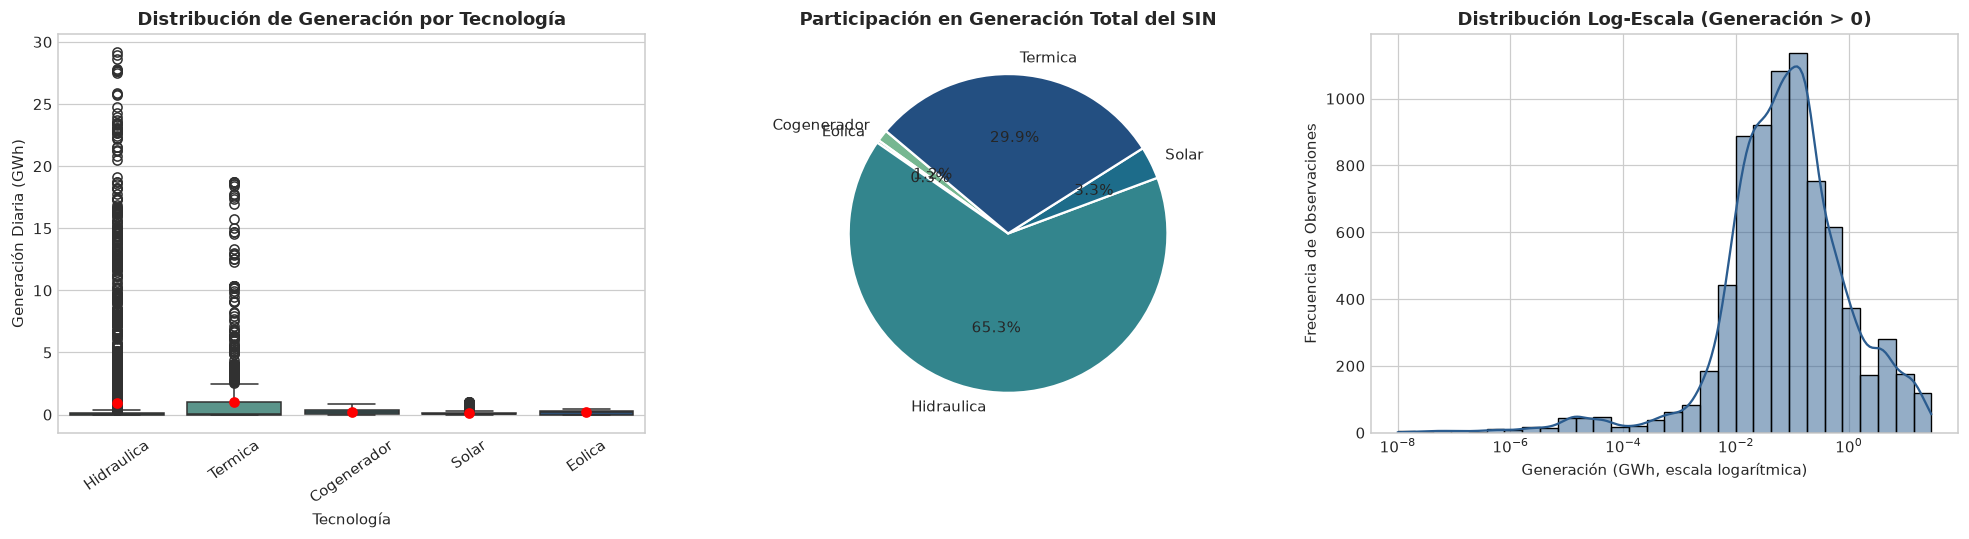

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Boxplot por tipo de tecnología (GWh para legibilidad)
df_plot = df_generacion.copy()
df_plot["Generacion_GWh"] = df_plot["GeneracionRealEstimada"] / 1e6

sns.boxplot(
    data=df_plot,
    x="TipoGeneracion",
    y="Generacion_GWh",
    ax=axes[0],
    palette="crest",
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "red"},
)
axes[0].set_title("Distribución de Generación por Tecnología", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Tecnología")
axes[0].set_ylabel("Generación Diaria (GWh)")
axes[0].tick_params(axis="x", rotation=35)

# 2. Participación en la canasta de generación
tech_share = df_generacion.groupby("TipoGeneracion")["GeneracionRealEstimada"].sum()
colors = sns.color_palette("crest", len(tech_share))
axes[1].pie(
    tech_share,
    labels=tech_share.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[1].set_title("Participación en Generación Total del SIN", fontsize=12, fontweight="bold")

# 3. Histograma y KDE en escala logarítmica (filtrando ceros para log)
positive_gen = df_plot.loc[df_plot["Generacion_GWh"] > 0, "Generacion_GWh"]
sns.histplot(
    positive_gen,
    kde=True,
    ax=axes[2],
    color="#2b5c8f",
    log_scale=True,
    bins=30,
)
axes[2].set_title("Distribución Log-Escala (Generación > 0)", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Generación (GWh, escala logarítmica)")
axes[2].set_ylabel("Frecuencia de Observaciones")

plt.tight_layout()
plt.show()


## 11. Patrones Temporales: Comportamiento por Día de la Semana y Evolución

Examinamos la estacionalidad del despacho eléctrico a lo largo de la semana:
- Variación de generación entre días laborales (Lunes a Viernes) y fines de semana (Sábado y Domingo), impulsada por la curva de carga industrial y comercial.
- Evolución acumulada diaria en el período.

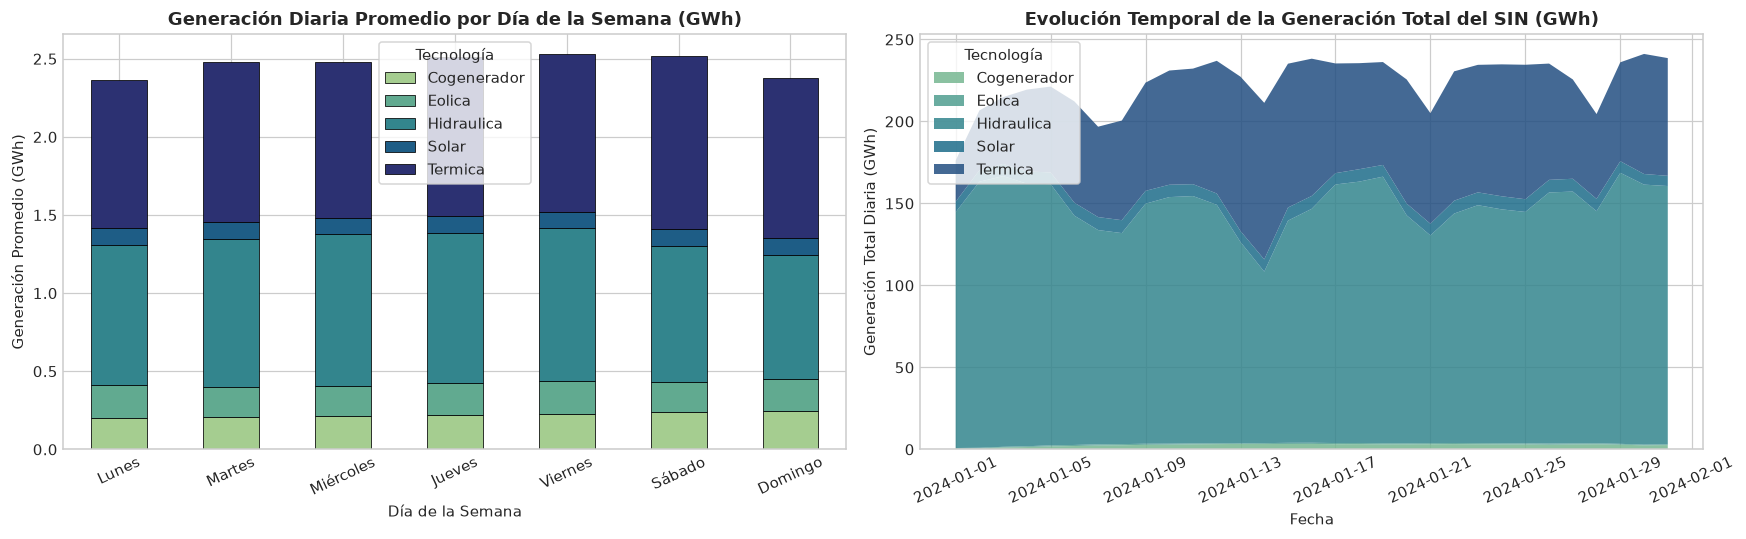

In [10]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
weekday_labels_es = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo",
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Perfil semanal promedio por tecnología (GWh)
weekly_tech = (
    df_generacion.groupby(["day_name", "TipoGeneracion"])["GeneracionRealEstimada"]
    .mean()
    .unstack()
    .reindex(weekday_order)
    / 1e6
)
weekly_tech.index = weekday_labels_es

weekly_tech.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    colormap="crest",
    edgecolor="black",
    linewidth=0.5,
)
axes[0].set_title("Generación Diaria Promedio por Día de la Semana (GWh)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Día de la Semana")
axes[0].set_ylabel("Generación Promedio (GWh)")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(title="Tecnología", frameon=True)

# 2. Evolución diaria acumulada del sistema por tecnología
daily_tech = (
    df_generacion.groupby(["Date", "TipoGeneracion"])["GeneracionRealEstimada"]
    .sum()
    .unstack()
    .fillna(0)
    / 1e6
)
axes[1].stackplot(
    daily_tech.index,
    daily_tech.values.T,
    labels=daily_tech.columns,
    alpha=0.85,
    colors=sns.color_palette("crest", daily_tech.shape[1]),
)
axes[1].set_title("Evolución Temporal de la Generación Total del SIN (GWh)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Generación Total Diaria (GWh)")
axes[1].legend(title="Tecnología", loc="upper left", frameon=True)
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


## 12. Análisis de Desviaciones: Generación Programada vs. Generación Real

Una de las señales operativas más potentes para la detección de anomalías en el SIN es la **discrepancia entre la programación y la realidad**:
- $\Delta = \text{GeneracionRealEstimada} - \text{GeneracionProgramadaRedespacho}$

Desviaciones extremas indican caídas súbitas de planta por falla forzada, restricciones severas de transporte en la red de transmisión o redespachos de emergencia por seguridad energética.

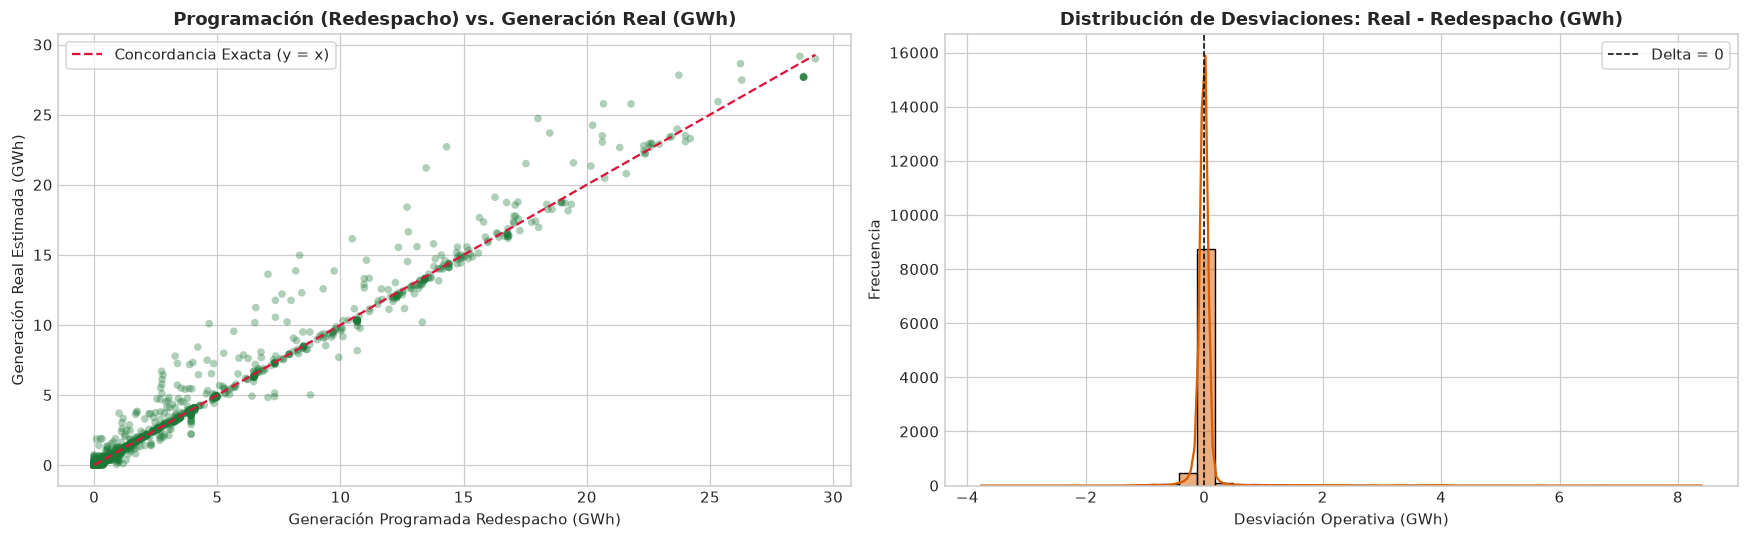

Top 5 Plantas con Mayores Desviaciones Absolutas Promedio (GWh):


,Desviacion_Abs_Media_GWh
CodigoPlanta,
SNCR,2.29
GVIO,2.26
CHVR,1.46
CHBG,0.97
ALBG,0.92


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Scatter Programada Redespacho vs Real Estimada (en GWh)
g_prog_gwh = df_generacion["GeneracionProgramadaRedespacho"] / 1e6
g_real_gwh = df_generacion["GeneracionRealEstimada"] / 1e6

axes[0].scatter(g_prog_gwh, g_real_gwh, alpha=0.35, color="#1b7837", edgecolors="none", s=25)
max_val = max(g_prog_gwh.max(), g_real_gwh.max())
axes[0].plot([0, max_val], [0, max_val], color="crimson", linestyle="--", linewidth=1.5, label="Concordancia Exacta (y = x)")
axes[0].set_title("Programación (Redespacho) vs. Generación Real (GWh)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Generación Programada Redespacho (GWh)")
axes[0].set_ylabel("Generación Real Estimada (GWh)")
axes[0].legend(frameon=True)

# 2. Distribución de desviaciones operativas Delta (GWh)
delta_gwh = df_generacion["Delta_Redespacho"] / 1e6
sns.histplot(
    delta_gwh,
    kde=True,
    ax=axes[1],
    color="#d95f02",
    bins=40,
)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1, label="Delta = 0")
axes[1].set_title("Distribución de Desviaciones: Real - Redespacho (GWh)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Desviación Operativa (GWh)")
axes[1].set_ylabel("Frecuencia")
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

# Top 5 plantas con mayores desviaciones absolutas promedio
print("Top 5 Plantas con Mayores Desviaciones Absolutas Promedio (GWh):")
top_dev_plants = (
    df_generacion.groupby("CodigoPlanta")["Delta_Redespacho"]
    .apply(lambda s: s.abs().mean() / 1e6)
    .sort_values(ascending=False)
    .head(5)
)
display(top_dev_plants.rename("Desviacion_Abs_Media_GWh").to_frame())


## 13. Correlaciones Operativas y Dependencias Cruzadas entre Plantas

Se evalúan dos niveles de correlación:
1. **Correlación de Pearson y Spearman** entre las variables cuantitativas de operación y las características temporales de calendario.
2. **Matriz de correlación cruzada** entre el top 10 de centrales generadoras más grandes del SIN, evaluando acoplamientos hidrotérmicos y sustitución de recursos.

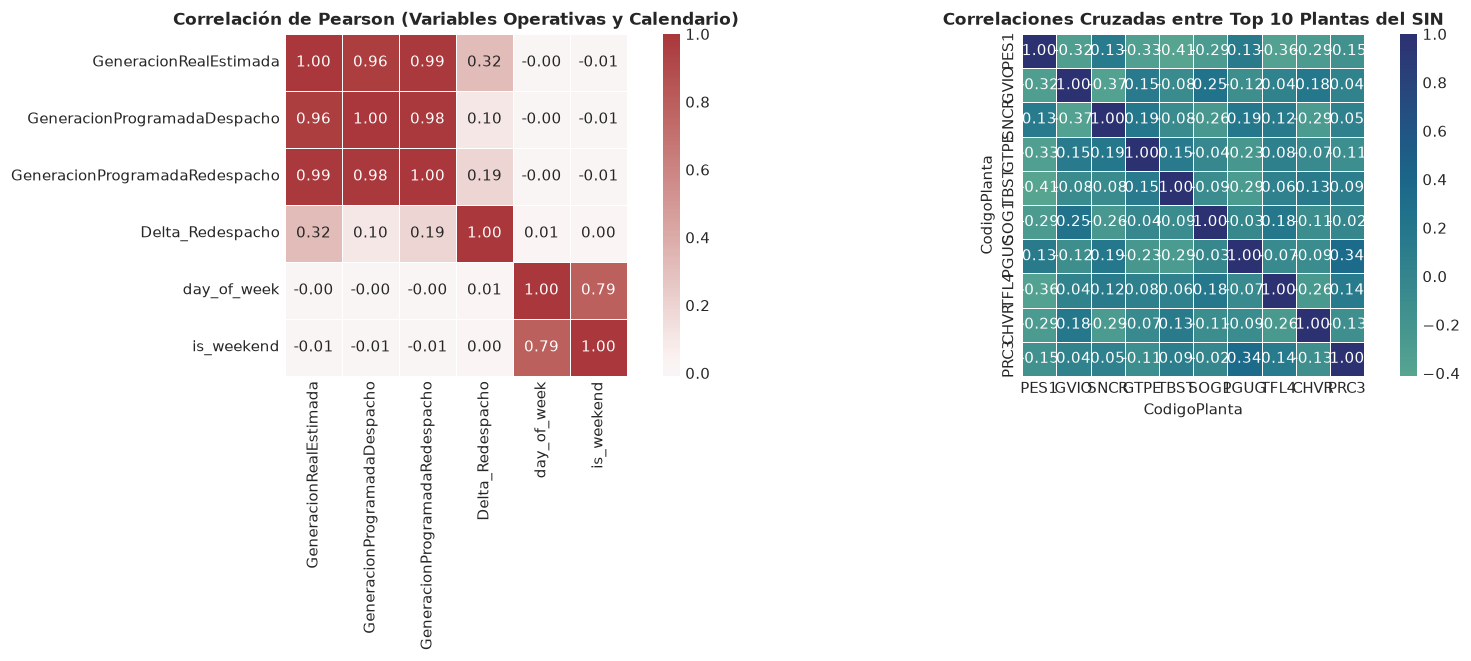

In [12]:
# 1. Matriz de correlación de variables operativas
num_cols = [
    "GeneracionRealEstimada",
    "GeneracionProgramadaDespacho",
    "GeneracionProgramadaRedespacho",
    "Delta_Redespacho",
    "day_of_week",
    "is_weekend",
]
corr_pearson = df_generacion[num_cols].corr(method="pearson")
corr_spearman = df_generacion[num_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    corr_pearson,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    cbar=True,
    ax=axes[0],
    square=True,
    linewidths=0.5,
)
axes[0].set_title("Correlación de Pearson (Variables Operativas y Calendario)", fontsize=11, fontweight="bold")

# 2. Correlación cruzada entre el top 10 de plantas
top_10_names = top_plantas.index.tolist()
cross_corr_top = df_pivot[top_10_names].corr(method="pearson")

sns.heatmap(
    cross_corr_top,
    annot=True,
    fmt=".2f",
    cmap="crest",
    center=0,
    cbar=True,
    ax=axes[1],
    square=True,
    linewidths=0.5,
)
axes[1].set_title("Correlaciones Cruzadas entre Top 10 Plantas del SIN", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


## 14. Línea Base de Detección de Anomalías: IQR vs. Preparación Multivariada

### 14.1. Limitaciones del enfoque univariado tradicional
El criterio de Tukey (IQR) aplicado variable por variable es insensible al contexto del sistema:
- Una planta apagada (generación 0) es habitual si los embalses están bajos o la planta térmica no entra por mérito de precio.
- Sin embargo, que una planta mayor se apague súbitamente en un día de demanda récord representa una **anomalía crítica**.

### 14.2. Preparación para Modelos Multivariados (Autoencoders)
Siguiendo la metodología de `docs/escenarios/escenario_03.md`, la matriz pivoteada $X_{\text{scaled}}$ normalizada por z-score por cada planta es el insumo para entrenar el autocodificador:
$$\hat{X} = f_{\theta}(X_{\text{scaled}})$$
$$e_t = \| X_t - \hat{X}_t \|^2_2$$
donde el error de reconstrucción multivariado $e_t$ en cada período $t$ señala el grado de anomalía en el estado global del sistema.

In [13]:
# 1. Detección univariada por IQR sobre las desviaciones operativas
stats_delta = compute_extended_statistics(df_generacion["Delta_Redespacho"], "Delta_Redespacho")
iqr_low = stats_delta["Umbral_Inf_IQR"]
iqr_upp = stats_delta["Umbral_Sup_IQR"]

outliers_univariados = df_generacion[
    (df_generacion["Delta_Redespacho"] < iqr_low) | (df_generacion["Delta_Redespacho"] > iqr_upp)
]

print(f"--- Detección Univariada (IQR sobre Delta_Redespacho) ---")
print(f"Umbral inferior: {iqr_low / 1e6:,.2f} GWh | Umbral superior: {iqr_upp / 1e6:,.2f} GWh")
print(f"Observaciones candidatas a anomalía univariada: {len(outliers_univariados):,} ({len(outliers_univariados) / len(df_generacion) * 100:.2f}%)")

# 2. Normalización matricial z-score por planta (vectorizada con pandas y numpy)
pivot_means = df_pivot.mean()
pivot_stds = df_pivot.std().replace(0.0, 1.0) # Evitar división por cero en plantas constantes
X_scaled = (df_pivot - pivot_means) / pivot_stds

print(f"\n--- Preparación Multivariada para Autoencoder ---")
print(f"Matriz escalada X_scaled: {X_scaled.shape[0]} muestras temporales x {X_scaled.shape[1]} dimensiones de entrada.")
print(f"Media global: {X_scaled.values.mean():.4f} | Varianza promedio: {X_scaled.values.var():.4f}")

# Cálculo ilustrativo de distancia euclidiana al centroide como señal base multivariada
dist_centroide = np.linalg.norm(X_scaled.values, axis=1)
threshold_multiv = np.percentile(dist_centroide, 95)
anomalias_multiv = np.where(dist_centroide > threshold_multiv)[0]

print(f"Períodos temporales con mayor desviación multivariada (Percentil 95): {len(anomalias_multiv)} días señalados.")
display(pd.DataFrame({
    "Fecha": df_pivot.index[anomalias_multiv],
    "Distancia_Multivariada": dist_centroide[anomalias_multiv]
}).head(5))


--- Detección Univariada (IQR sobre Delta_Redespacho) ---
Umbral inferior: -0.03 GWh | Umbral superior: 0.03 GWh
Observaciones candidatas a anomalía univariada: 2,231 (23.37%)

--- Preparación Multivariada para Autoencoder ---
Matriz escalada X_scaled: 31 muestras temporales x 308 dimensiones de entrada.
Media global: -0.0000 | Varianza promedio: 0.9018
Períodos temporales con mayor desviación multivariada (Percentil 95): 2 días señalados.


,Fecha,Distancia_Multivariada
0,2024-01-01,31.35
1,2024-01-02,24.26


## 15. Síntesis de Hallazgos, Interpretación y Hoja de Ruta MLOps

### 15.1. Conclusiones Principales del Análisis Exploratorio
1. **Riqueza Estructural del Dataset `E17D25`:**
   - La granularidad por planta permite modelar el SIN como una red de series temporales acopladas ($N \approx 300$ centrales).
   - Se evidencian regímenes operacionales heterogéneos: plantas hidroeléctricas de base (alta inercia), térmicas de ciclo combinado y renovables no convencionales (solar/eólica con alta intermitencia).
2. **Desviaciones Operativas (Redespacho vs. Real):**
   - La distribución de las desviaciones presenta colas pesadas (alta curtosis), lo cual valida la existencia de eventos extremos no capturables por supuestos gaussianos simples.
3. **Justificación del Enfoque Híbrido:**
   - Los métodos univariados (IQR) confunden la inactividad programada de plantas con anomalías. El modelado multivariado (Autoencoders + Isolation Forest sobre la matriz $N \times T$) es indispensable para capturar restricciones de red y sustitución entre centrales.

### 15.2. Integración en la Arquitectura de Microservicios (MLOps)
De acuerdo con los objetivos del trabajo de investigación (`docs/hallazgos.md`):
- **Microservicio de Ingesta:** Extracción programada por lotes usando `ReadSIMEM` con control de reintentos y tolerancia a fallos.
- **Microservicio de Preprocesamiento:** Transformación matricial `build_plant_pivot_matrix` con imputación de ceros y escalado robusto.
- **Microservicio de Detección Híbrida:** Ensamble de puntuaciones normalizadas:
  $$S_t = w_{\text{stat}} S_{\text{IQR}} + w_{\text{ml}} S_{\text{IForest}} + w_{\text{dl}} S_{\text{Autoencoder}}$$
- **Microservicio de Visualización:** Exposición en tablero interactivo para que los operadores analicen la señal global y las plantas con mayor contribución al error de reconstrucción.